In [18]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
import time

Here I have base and keypoint detection functions. I'm not using most of them in the main code flow, I'm using the cv2 functions to detect keypoints.

In [19]:
def kernel(image, x,y):
    return image[x-1:x+2, y-1:y+2]

def bound(image):
    image = np.insert(image, 0, 0, axis=0)
    image = np.insert(image, image.shape[0], 0, axis=0)
    image = np.insert(image, 0, 0, axis=1)
    image = np.insert(image, image.shape[1], 0, axis=1)
    for j in range(image.shape[0]):
        image[j,0] = image[j,1]
        image[j,image.shape[1]-1] = image[j,image.shape[1]-2]
    for j in range(image.shape[1]):
        image[0,j] = image[1,j]
        image[image.shape[0]-1,j] = image[image.shape[0]-2,j]


    return image

def unbound(image):
    image = np.delete(image, 0, axis=0)
    image = np.delete(image, 0, axis=1)
    image = np.delete(image, image.shape[0]-1, axis=0)
    image = np.delete(image, image.shape[1]-1, axis=1)
    return image

def gaussian(image):
    kernel_gaussian = np.array([[1,2,1],[2,4,2],[1,2,1]])/16
    image = bound(image)
    new_image = np.zeros(image.shape)
    for x in range(1,image.shape[0]-1):
        for y in range(1,image.shape[1]-1):
            new_image[x,y] = np.sum(image[x-1:x+2, y-1:y+2]*kernel_gaussian)
    return unbound(new_image)

def scaler(image,scale_count=4,gaussian_count=5):
    scales = []
    for i in range(scale_count):
        scales.append(cv2.resize(image, (0,0), fx=1/2**(i), fy=1/2**(i)))
    gaussian_scales = []
    for i in scales:
        gaussian_scales.append(i)
        for _ in range(gaussian_count-1):
            gaussian_scales.append(gaussian(gaussian_scales[-1]))
    return gaussian_scales

def normalize(image):
    image = image - np.min(image)
    image = image / np.max(image) * 255
    return image

def dog(image, scale_count=4, gaussian_count=5):
    scales = scaler(image, scale_count, gaussian_count)
    dog_scales = []
    for i in range(scale_count):
        for j in range(1, gaussian_count):
            dog_scales.append(scales[i*gaussian_count+j]-scales[i*gaussian_count+j-1])
    return dog_scales

def local_max_min(dog_scales, octaves=4, scales=5, threshold=0.5):
    images=[]
    for i in range(octaves):
        images.append(np.zeros(dog_scales[i*(scales-1)].shape))
        first_free_scale = np.zeros(dog_scales[i*(scales-1)].shape)
        last_free_scale = np.zeros(dog_scales[i*(scales-1)].shape)
        scale_list = [first_free_scale] + dog_scales[i*(scales-1):(i+1)*(scales-1)] + [last_free_scale]
        for i in scale_list:
            i = bound(i)
        for j in range(1,len(scale_list)-1):
            for x in range(1,scale_list[j].shape[0]-1):
                for y in range(1,scale_list[j].shape[1]-1):
                    if scale_list[j][x,y] > threshold:
                        if scale_list[j][x,y] > scale_list[j-1][x-1:x+2, y-1:y+2].max() and scale_list[j][x,y] > scale_list[j+1][x-1:x+2, y-1:y+2].max() and scale_list[j][x,y] == scale_list[j][x-1:x+2, y-1:y+2].max():
                            images[-1][x,y] = scale_list[j][x,y]
                        if scale_list[j][x,y] < scale_list[j-1][x-1:x+2, y-1:y+2].min() and scale_list[j][x,y] < scale_list[j+1][x-1:x+2, y-1:y+2].min() and scale_list[j][x,y] == scale_list[j][x-1:x+2, y-1:y+2].min():
                            images[-1][x,y] = scale_list[j][x,y]
    return images

def normalize_with_threshold(image, threshold):
    image = image - np.min(image)
    image = image / np.max(image) * 255
    image = np.where(image > threshold, image, 0)
    return image

def orientation_finder(image):
    image = bound(image)
    new_image = np.zeros(image.shape)
    for x in range(1,image.shape[0]-1):
        for y in range(1,image.shape[1]-1):
            new_image[x,y] = np.arctan2(int(image[x+1,y])-int(image[x-1,y]),int(image[x,y+1])-int(image[x,y-1]))

    return unbound(new_image)


There are feature extraction and feature matching functions. As I said the previous markdown, I used cv2 to extract features. But I did not use cv2 wwhile matching.

In [20]:
def feature_extract_sift(image):
    sift = cv2.xfeatures2d.SIFT_create()
    keypoints, descriptors = sift.detectAndCompute(image, None)
    return keypoints, descriptors

def feature_extract_surf(image):
    surf = cv2.xfeatures2d.SURF_create()
    keypoints, descriptors = surf.detectAndCompute(image, None)
    return keypoints, descriptors

def feature_extract_orb(image):
    orb = cv2.ORB_create()
    keypoints, descriptors = orb.detectAndCompute(image, None)
    return keypoints, descriptors

def feature_match_normalized_correlation(descriptors1, descriptors2):
    matches = []
    descriptors1_mean = np.mean(descriptors1, axis=0)
    descriptors2_mean = np.mean(descriptors2, axis=0)
    for i in range(descriptors1.shape[0]):
        for j in range(descriptors2.shape[0]):
            meaned_1 = descriptors1[i] - descriptors1_mean
            meaned_2 = descriptors2[j] - descriptors2_mean
            matches.append((i,j,np.sum(meaned_1*meaned_2)/np.linalg.norm(meaned_1)/np.linalg.norm(meaned_2)))
    matches = sorted(matches, key=lambda x: x[2], reverse=True)
    return matches



There are kmeans, knn and histogram functions. I have some functions that I'm not using right now. There are no cv2 or sklearn usage in these functions.
There are knn functions which are euclidean, cosine and chi2.

In [21]:

def kmeans_descriptors(descriptors, k, max_iter=100, tol=1e-4):

    n_samples, n_features = descriptors.shape

    centroids = np.random.choice(n_samples, k, replace=False)
    centroids = descriptors[centroids]

    for _ in range(max_iter):
        old_centroids = centroids.copy()

        distances = np.linalg.norm(descriptors.reshape(-1, 1, n_features) - centroids, axis=2)
        labels = np.argmin(distances, axis=1)

        for j in range(k):
            cluster_descriptors = descriptors[labels == j]
            if cluster_descriptors.shape[0] > 0: 
                centroids[j] = np.mean(cluster_descriptors, axis=0)

        centroid_shift = np.linalg.norm(old_centroids - centroids, axis=1)
        if np.all(centroid_shift < tol):
            break

    return centroids, labels
def distance(x1, x2):

  return np.sqrt(np.sum((x1 - x2) ** 2))

def kmeans(data, k, max_iterations=100):
  centroids = data[np.random.choice(len(data), k, replace=False)]

  for iter in range(max_iterations):
    print(iter)
    labels = np.argmin([distance(x, c) for c in centroids] for x in data)

    new_centroids = np.array([np.mean(data[labels == i], axis=0) for i in range(k)])

    if np.all(np.linalg.norm(centroids - new_centroids, axis=1) < 1e-6):
      break

    centroids = new_centroids

  return centroids, labels

def kmeans_descriptors_batch(descriptors, k, max_iter=100, tol=1e-4, batch_size=1000):
    n_samples, n_features = descriptors.shape
    centroids = np.random.choice(n_samples, k, replace=False)
    centroids = descriptors[centroids]

    for iter in range(max_iter):
        old_centroids = centroids.copy()
        print(iter)

        distances = []
        for i in range(0, n_samples, batch_size):
            batch_descriptors = descriptors[i:i + batch_size]
            batch_distances = np.linalg.norm(batch_descriptors[:, None, :] - centroids, axis=2)
            distances.append(batch_distances)

        distances = np.concatenate(distances, axis=0)
        labels = np.argmin(distances, axis=1)

        # ... rest of the code remains the same ...

    return centroids, labels
def histogram_of_visual_words(descriptors, centroids):
    distances = np.linalg.norm(descriptors.reshape(-1, 1, descriptors.shape[1]) - centroids, axis=2)
    # is there any way to calculate distances without reshaping?
    distances 
    labels = np.argmin(distances, axis=1)
    histogram = np.bincount(labels, minlength=centroids.shape[0])
    return histogram

def knn_euclidean_classifier(histograms, labels, test_histogram, k):
    distances = np.linalg.norm(histograms - test_histogram, axis=1)
    indices = np.argsort(distances)[:k]
    nearest_labels = labels[indices]
    return np.argmax(np.bincount(nearest_labels))

def knn_cosine_classifier(histograms, labels, test_histogram, k):
    distances = np.dot(histograms, test_histogram) / (np.linalg.norm(histograms, axis=1) * np.linalg.norm(test_histogram))
    indices = np.argsort(distances)[::-1][:k]
    nearest_labels = labels[indices]
    return np.argmax(np.bincount(nearest_labels))

def knn_chi2_classifier(histograms, labels, test_histogram, k):
    distances = np.sum((histograms - test_histogram) ** 2 / (histograms + test_histogram + 1e-6), axis=1)
    indices = np.argsort(distances)[:k]
    nearest_labels = labels[indices]
    return np.argmax(np.bincount(nearest_labels))



There are functions to draw confusion matrix.

In [22]:
def confusion_matrix(true_labels, predicted_labels):
    confusion_matrix = np.zeros((len(np.unique(true_labels)), len(np.unique(true_labels))))
    for i in range(len(true_labels)):
        confusion_matrix[true_labels[i], predicted_labels[i]] += 1
    return confusion_matrix

def draw_confusion_matrix(confusion_matrix):
    plt.imshow(confusion_matrix, cmap='viridis')
    plt.xlabel('Predicted labels')
    plt.ylabel('True labels')
    plt.colorbar()
    plt.show()

It shows how to detect keypoints.

In [23]:
#KEYPOINT DETECTION
image = cv2.imread("imagenette2/train/n03445777/ILSVRC2012_val_00007755.JPEG", cv2.IMREAD_GRAYSCALE)
sift = feature_extract_sift(image)
image = cv2.drawKeypoints(image, sift[0], None)
cv2.imwrite("keypoint_detection.jpg", image)

True

There is an example of keypoint detection.

![title](keypoint_detection.jpg)

This part shows how to match features. As I said before, Im using my own matching function.

In [24]:
#FEATURE MATCHING

image1 = cv2.imread('imagenette2/train/n03445777/ILSVRC2012_val_00007755.JPEG', cv2.IMREAD_GRAYSCALE)
image2 = cv2.imread('imagenette2/train/n03445777/n03445777_13067.JPEG', cv2.IMREAD_GRAYSCALE)

keypoints1, descriptors1 = feature_extract_sift(image1)
keypoints2, descriptors2 = feature_extract_sift(image2)

matches = feature_match_normalized_correlation(descriptors1, descriptors2)
matches = matches[:10]
matches1to2 = []
for match in matches:
    matches1to2.append(cv2.DMatch(match[0], match[1], 0))

image = cv2.drawMatches(image1, keypoints1, image2, keypoints2, matches1to2, None)
cv2.imwrite("feature_matching.jpg", image)



True

There is an example of feature matching. Since examples are different pictures and almost there are no literally same parts, the matching is not that good.
If we use different dataset with similiar items. We would see the matching was better.

![title](feature_matching.jpg)

This part contains BoW formation and classification with SIFT.

(1110458, 128)
1713612932.3046484
1713613673.8965445
Euclidean Accuracy for n01440764 is 0.5762273901808785
Cosine Accuracy for n01440764 is 0.5943152454780362
Chi2 Accuracy for n01440764 is 0.5917312661498708
Euclidean Accuracy for n02102040 is 0.5443037974683544
Cosine Accuracy for n02102040 is 0.44556962025316454
Chi2 Accuracy for n02102040 is 0.5417721518987342
Euclidean Accuracy for n02979186 is 0.5462184873949579
Cosine Accuracy for n02979186 is 0.22408963585434175
Chi2 Accuracy for n02979186 is 0.5546218487394958
Euclidean Accuracy for n03000684 is 0.23575129533678757
Cosine Accuracy for n03000684 is 0.18134715025906736
Chi2 Accuracy for n03000684 is 0.25129533678756477
Euclidean Accuracy for n03028079 is 0.26894865525672373
Cosine Accuracy for n03028079 is 0.2713936430317848
Chi2 Accuracy for n03028079 is 0.26405867970660146
Euclidean Accuracy for n03394916 is 0.5456852791878173
Cosine Accuracy for n03394916 is 0.5
Chi2 Accuracy for n03394916 is 0.5228426395939086
Euclidean Acc

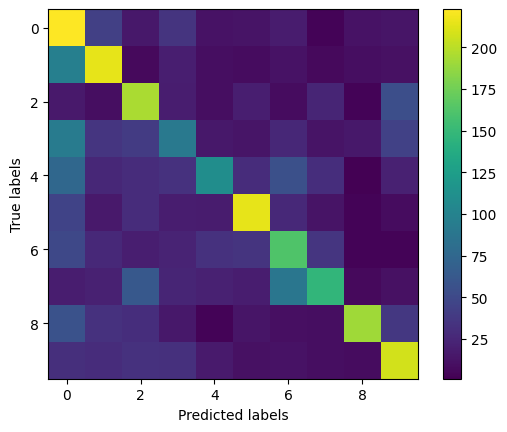

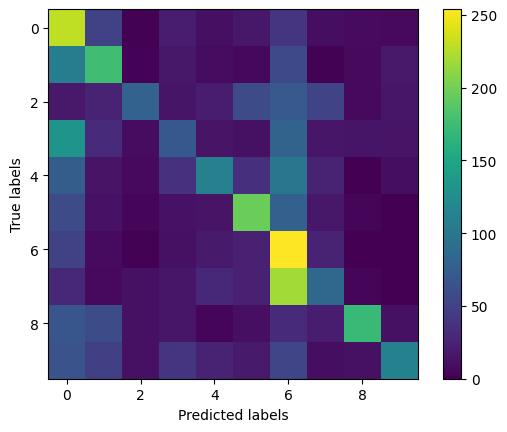

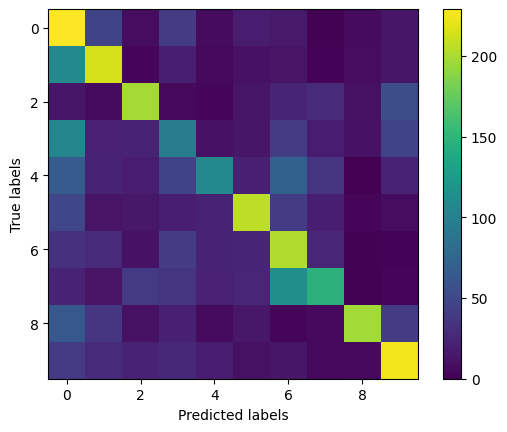

Total Euclidean Accuracy is 0.44764331210191083
Total Cosine Accuracy is 0.3788535031847134
Total Chi2 Accuracy is 0.46420382165605095


In [25]:
#SIFT
train_folder = 'imagenette2/train'
val_folder = 'imagenette2/val'
histograms = []
image_labels = []

train_folders = os.listdir(train_folder)
val_folders = os.listdir(val_folder)
all_descriptors = []
total_images = 0
for i, folder in enumerate(train_folders):
    for image_name in os.listdir(os.path.join(train_folder, folder)):
        total_images += 1
        image = cv2.imread(os.path.join(train_folder, folder, image_name), cv2.IMREAD_GRAYSCALE)
        keypoints, descriptors = feature_extract_sift(image)
        if descriptors is not None:
            descriptors = descriptors.astype(np.float32)
            all_descriptors.append(descriptors)
np.random.seed(0)
sample_idx = np.random.randint(0, total_images+1, 1000).tolist()
descriptors_sample = []
for n in sample_idx:
    if n < len(all_descriptors):
        descriptors_sample.append(np.array(all_descriptors[n]))
all_descriptors = []
for img_descriptors in descriptors_sample:
    for descriptor in img_descriptors:
        all_descriptors.append(descriptor)
all_descriptors = np.stack(all_descriptors)
print(all_descriptors.shape)
# centroids, labels = kmeans_descriptors_batch(all_descriptors, 200,20)
print(time.time())
kmeans = cv2.kmeans(all_descriptors, 200, None, (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 20, 1.0), 30, cv2.KMEANS_RANDOM_CENTERS)
print(time.time())
centroids = kmeans[2]
labels = kmeans[1]
histograms = []
for i, folder in enumerate(train_folders):
    for image_name in os.listdir(os.path.join(train_folder, folder)):
        image = cv2.imread(os.path.join(train_folder, folder, image_name), cv2.IMREAD_GRAYSCALE)
        keypoints, descriptors = feature_extract_sift(image)
        if descriptors is not None:
            descriptors = descriptors.astype(np.float32)
            histogram = histogram_of_visual_words(descriptors, centroids)
            histograms.append(histogram)
            image_labels.append(i)

histograms = np.array(histograms)
image_labels = np.array(image_labels)
total_total = 0
correct_total_euclidean = 0
correct_total_cosine = 0
correct_total_chi2 = 0
predicted_labels_euclidean = []
predicted_labels_cosine = []
predicted_labels_chi2 = []
true_labels = []
for i, folder in enumerate(val_folders):
    correct_euclidean = 0
    correct_cosine = 0
    correct_chi2 = 0
    total = 0
    for image_name in os.listdir(os.path.join(val_folder, folder)):
        image = cv2.imread(os.path.join(val_folder, folder, image_name), cv2.IMREAD_GRAYSCALE)
        keypoints, descriptors = feature_extract_sift(image)
        descriptors = descriptors.astype(np.float32)
        histogram = histogram_of_visual_words(descriptors, centroids)
        label_euclidean = knn_euclidean_classifier(histograms, image_labels, histogram, 5)
        label_cosine = knn_cosine_classifier(histograms, image_labels, histogram, 5)
        label_chi2 = knn_chi2_classifier(histograms, image_labels, histogram, 5)
        predicted_labels_euclidean.append(label_euclidean)
        predicted_labels_cosine.append(label_cosine)
        predicted_labels_chi2.append(label_chi2)
        true_labels.append(i)
        if label_euclidean == i:
            correct_euclidean += 1
        if label_cosine == i:
            correct_cosine += 1
        if label_chi2 == i:
            correct_chi2 += 1
        total += 1
    correct_total_euclidean += correct_euclidean
    correct_total_cosine += correct_cosine
    correct_total_chi2 += correct_chi2
    total_total += total
    print(f'Euclidean Accuracy for {folder} is {correct_euclidean/total}')
    print(f'Cosine Accuracy for {folder} is {correct_cosine/total}')
    print(f'Chi2 Accuracy for {folder} is {correct_chi2/total}')
confusion_m_euclidean = confusion_matrix(true_labels, predicted_labels_euclidean)
confusion_m_cosine = confusion_matrix(true_labels, predicted_labels_cosine)
confusion_m_chi2 = confusion_matrix(true_labels, predicted_labels_chi2)
draw_confusion_matrix(confusion_m_euclidean)
draw_confusion_matrix(confusion_m_cosine)
draw_confusion_matrix(confusion_m_chi2)
print(f'Total Euclidean Accuracy is {correct_total_euclidean/total_total}')
print(f'Total Cosine Accuracy is {correct_total_cosine/total_total}')
print(f'Total Chi2 Accuracy is {correct_total_chi2/total_total}')




This part contains BoW formation and classification with ORB.

(4417464, 32)
1713616163.3096406
1713617060.7179115
Euclidean Accuracy for n01440764 is 0.39896373056994816
Cosine Accuracy for n01440764 is 0.28756476683937826
Chi2 Accuracy for n01440764 is 0.37305699481865284
Euclidean Accuracy for n02102040 is 0.3037974683544304
Cosine Accuracy for n02102040 is 0.4506329113924051
Chi2 Accuracy for n02102040 is 0.3594936708860759
Euclidean Accuracy for n02979186 is 0.4005602240896359
Cosine Accuracy for n02979186 is 0.1876750700280112
Chi2 Accuracy for n02979186 is 0.35014005602240894
Euclidean Accuracy for n03000684 is 0.18882978723404256
Cosine Accuracy for n03000684 is 0.1622340425531915
Chi2 Accuracy for n03000684 is 0.17553191489361702
Euclidean Accuracy for n03028079 is 0.14425427872860636
Cosine Accuracy for n03028079 is 0.19315403422982885
Chi2 Accuracy for n03028079 is 0.1466992665036675
Euclidean Accuracy for n03394916 is 0.35279187817258884
Cosine Accuracy for n03394916 is 0.42385786802030456
Chi2 Accuracy for n03394916 is 0.3934010152284

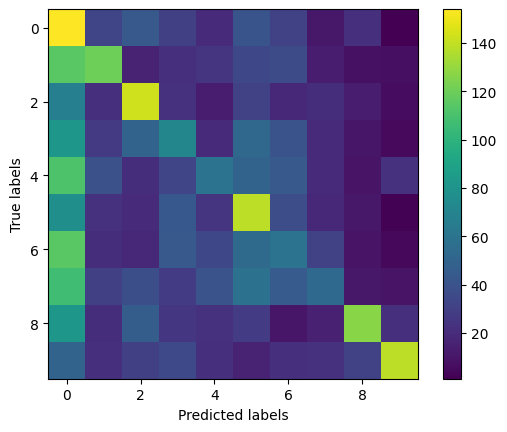

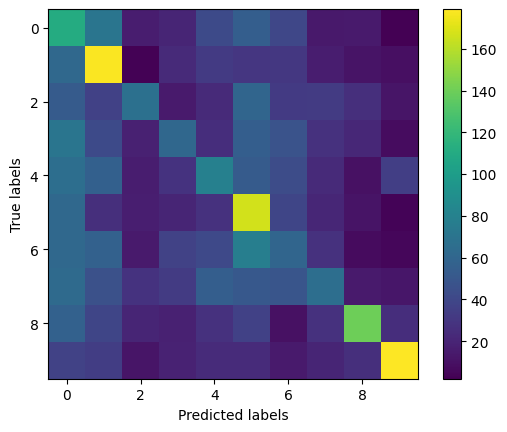

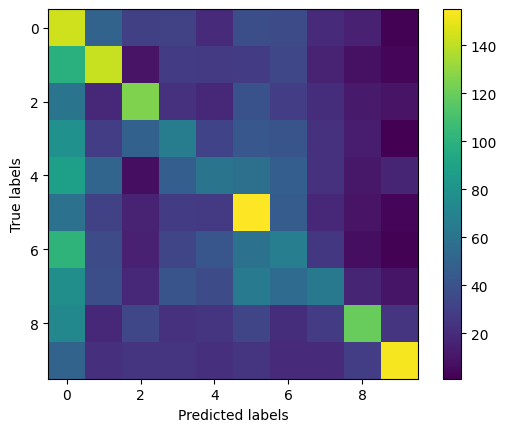

Total Euclidean Accuracy is 0.27184466019417475
Total Cosine Accuracy is 0.28308635666836995
Total Chi2 Accuracy is 0.2795094532447624


In [26]:
#ORB
train_folder = 'imagenette2/train'
val_folder = 'imagenette2/val'
histograms = []
image_labels = []

train_folders = os.listdir(train_folder)
val_folders = os.listdir(val_folder)
all_descriptors = []
total_images = 0
for i, folder in enumerate(train_folders):
    for image_name in os.listdir(os.path.join(train_folder, folder)):
        total_images += 1
        image = cv2.imread(os.path.join(train_folder, folder, image_name), cv2.IMREAD_GRAYSCALE)
        keypoints, descriptors = feature_extract_orb(image)
        if descriptors is not None:
            descriptors = descriptors.astype(np.float32)
            all_descriptors.append(descriptors)
np.random.seed(0)
sample_idx = np.random.randint(0, total_images+1, total_images).tolist()
descriptors_sample = []
for n in sample_idx:
    if n < len(all_descriptors):
        descriptors_sample.append(np.array(all_descriptors[n]))
all_descriptors = []
for img_descriptors in descriptors_sample:
    for descriptor in img_descriptors:
        all_descriptors.append(descriptor)
all_descriptors = np.stack(all_descriptors)
print(all_descriptors.shape)
# centroids, labels = kmeans_descriptors_batch(all_descriptors, 200,20)
print(time.time())
kmeans = cv2.kmeans(all_descriptors, 200, None, (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 20, 1.0), 30, cv2.KMEANS_RANDOM_CENTERS)
print(time.time())
centroids = kmeans[2]
labels = kmeans[1]
histograms = []
for i, folder in enumerate(train_folders):
    for image_name in os.listdir(os.path.join(train_folder, folder)):
        image = cv2.imread(os.path.join(train_folder, folder, image_name), cv2.IMREAD_GRAYSCALE)
        keypoints, descriptors = feature_extract_orb(image)
        if descriptors is not None:
            descriptors = descriptors.astype(np.float32)
            histogram = histogram_of_visual_words(descriptors, centroids)
            histograms.append(histogram)
            image_labels.append(i)

histograms = np.array(histograms)
image_labels = np.array(image_labels)
total_total = 0
correct_total_euclidean = 0
correct_total_cosine = 0
correct_total_chi2 = 0
predicted_labels_euclidean = []
predicted_labels_cosine = []
predicted_labels_chi2 = []
true_labels = []
for i, folder in enumerate(val_folders):
    correct_euclidean = 0
    correct_cosine = 0
    correct_chi2 = 0
    total = 0
    for image_name in os.listdir(os.path.join(val_folder, folder)):
        image = cv2.imread(os.path.join(val_folder, folder, image_name), cv2.IMREAD_GRAYSCALE)
        keypoints, descriptors = feature_extract_orb(image)
        if descriptors is not None:
            descriptors = descriptors.astype(np.float32)
            histogram = histogram_of_visual_words(descriptors, centroids)
            label_euclidean = knn_euclidean_classifier(histograms, image_labels, histogram, 5)
            label_cosine = knn_cosine_classifier(histograms, image_labels, histogram, 5)
            label_chi2 = knn_chi2_classifier(histograms, image_labels, histogram, 5)
            predicted_labels_euclidean.append(label_euclidean)
            predicted_labels_cosine.append(label_cosine)
            predicted_labels_chi2.append(label_chi2)
            true_labels.append(i)
            if label_euclidean == i:
                correct_euclidean += 1
            if label_cosine == i:
                correct_cosine += 1
            if label_chi2 == i:
                correct_chi2 += 1
            total += 1
    correct_total_euclidean += correct_euclidean
    correct_total_cosine += correct_cosine
    correct_total_chi2 += correct_chi2
    total_total += total
    print(f'Euclidean Accuracy for {folder} is {correct_euclidean/total}')
    print(f'Cosine Accuracy for {folder} is {correct_cosine/total}')
    print(f'Chi2 Accuracy for {folder} is {correct_chi2/total}')
confusion_m_euclidean = confusion_matrix(true_labels, predicted_labels_euclidean)
confusion_m_cosine = confusion_matrix(true_labels, predicted_labels_cosine)
confusion_m_chi2 = confusion_matrix(true_labels, predicted_labels_chi2)
draw_confusion_matrix(confusion_m_euclidean)
draw_confusion_matrix(confusion_m_cosine)
draw_confusion_matrix(confusion_m_chi2)
print(f'Total Euclidean Accuracy is {correct_total_euclidean/total_total}')
print(f'Total Cosine Accuracy is {correct_total_cosine/total_total}')
print(f'Total Chi2 Accuracy is {correct_total_chi2/total_total}')




At all, I have some tries with changes and my last statistics with correlation graphs:

|  | KMEANS k | SIFT | ORB |
| --- | --- | --- | --- |
| EUCLIDEAN | k=100 | .445 | .264 |
| EUCLIDEAN | k=200 | .448 | .272 |
| COSINE | k=100 | .380 | .262 |
| COSINE | k=200 | .379 | .283 |
| CHI2 | k=100 | .461 | .264 |
| CHI2 | k=200 | .464 | .280 |

As we can see, SIFT is better at all the rows but it is a bit slower.

At SIFT, the change of the parameter k 100 to 200 doesn't affect the result that much. At ORB it affects a bit more.

At ORB, the change of classification method doesn't affect the result that much but at SIFT, the change of the method affects the results directly.

The best result comes from the SIFT-CHI2 with k=200.

There are all the correlation graphs of statistics:

We can see that 4th, 5th, 7th and 8th classes does not have high accuracies. We can see which classes' predictions are wrong and which ones predictions complicated with which one.

![title](saves/standart/sift-100-30/euclidean.png)
![title](saves/standart/orb-100-30/euclidean.png)
![title](saves/standart/sift-200-30/euclidean.png)
![title](saves/standart/orb-200-30/euclidean.png)
![title](saves/standart/sift-100-30/cosine.png)
![title](saves/standart/orb-100-30/cosine.png)
![title](saves/standart/sift-200-30/cosine.png)
![title](saves/standart/orb-200-30/cosine.png)
![title](saves/standart/sift-100-30/chi2.png)
![title](saves/standart/orb-100-30/chi2.png)
![title](saves/standart/sift-200-30/chi2.png)
![title](saves/standart/orb-200-30/chi2.png)
